In [1]:
import dotenv
import json
import os
import pickle as pkl
from typing import TypedDict, Literal, Any
from datetime import date, datetime, timedelta
from itertools import product

import dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from alpha_vantage import timeseries
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import yfinance as yf
import polygon as pg

In [2]:
schema = {
    'contractID': 'str',                     # String
    'symbol': 'str',                         # String
    'expiration': 'datetime',                # Date (should be a datetime)
    'strike': 'float',                       # Float
    'type': 'category',                      # "call" or "put", can be treated as category
    'last': 'float',                         # Float
    'mark': 'float',                         # Float
    'bid': 'float',                          # Float
    'bid_size': 'int',                       # Integer
    'ask': 'float',                          # Float
    'ask_size': 'int',                       # Integer
    'volume': 'int',                         # Integer
    'open_interest': 'int',                  # Integer
    'date': 'datetime',                      # Date (should be a datetime)
    'implied_volatility': 'float',           # Float
    'delta': 'float',                        # Float
    'gamma': 'float',                        # Float
    'theta': 'float',                        # Float
    'vega': 'float',                         # Float
    'rho': 'float'                           # Float
}

numeric_columns = [
    'strike', 'last', 'mark', 'bid', 'bid_size', 'ask', 'ask_size',
    'volume', 'open_interest', 'implied_volatility', 'delta', 'gamma',
    'theta', 'vega', 'rho'
]

In [3]:
def to_date(s: str) -> date:
    return date(*map(int, s.split("-")))

In [4]:
with open("dump.json", "r") as f:
    data = json.load(f)
    data = pd.DataFrame(data['data'])

    for column, dtype in schema.items():
        if dtype == 'int':
            data[column] = pd.to_numeric(data[column], errors='coerce', downcast='integer')
        elif dtype == 'float':
            data[column] = pd.to_numeric(data[column], errors='coerce', downcast='float')
        elif dtype == 'datetime':
            data[column] = pd.to_datetime(data[column], errors='coerce')
        elif dtype == 'category':
            data[column] = data[column].astype('category')
        elif dtype == 'str':
            data[column] = data[column].astype(str)

    data = data[data['bid_size'] > 0]

In [5]:
data = data[data['type'] == 'call']
# predictors = data.select_dtypes(include=[np.number]).columns.tolist()
predictors = numeric_columns.copy()
predictors.remove('implied_volatility')
data_X = data[predictors].to_numpy()
data_y = data['implied_volatility'].to_numpy()

print(f"Training model with {predictors}")
X_train, X_test, y_train, y_test = train_test_split(
    data_X, data_y, test_size=0.2, random_state=42
)

regr = linear_model.LinearRegression()
regr.fit(X_train, y_train)

y_pred = regr.predict(X_test)

print("Coefficients: \n", regr.coef_)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))

# Plot outputs
# plt.scatter(X_test[:, 8], y_test, color="black")
# plt.plot(X_test[:, 8], y_pred, color="blue", linewidth=3)
#
# plt.xticks(())
# plt.yticks(())

# plt.show()

Training model with ['strike', 'last', 'mark', 'bid', 'bid_size', 'ask', 'ask_size', 'volume', 'open_interest', 'delta', 'gamma', 'theta', 'vega', 'rho']
Coefficients: 
 [-2.99410429e-04  1.23228328e-02  2.10774350e+00 -1.08378255e+00
 -4.36406641e-04 -1.01900744e+00  1.63042801e-04  2.07300182e-05
  2.67382711e-06 -1.01095505e-01 -2.71785975e+00 -5.84925950e-01
  3.94296855e-01 -4.51581478e-01]
Mean squared error: 0.15
Coefficient of determination: 0.59


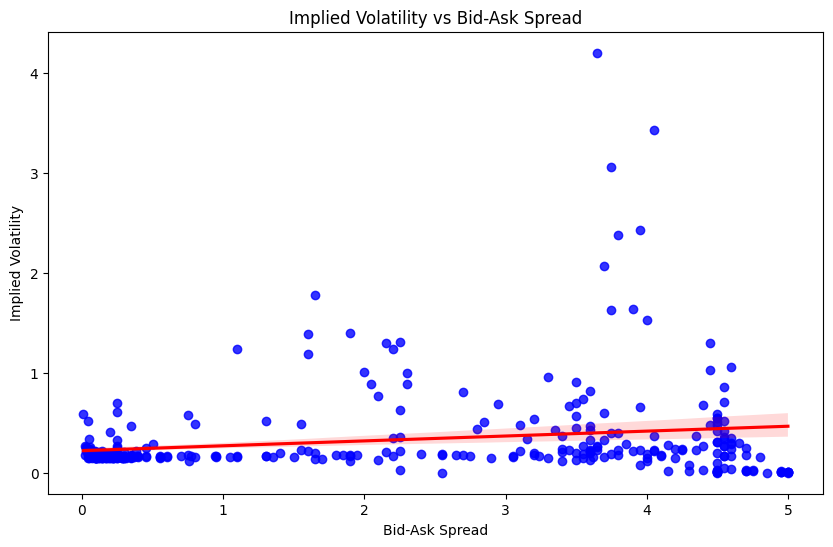

In [6]:
data['spread'] = data['ask'] - data['bid']
dt = data[(data['bid_size'] > 0) & (data['ask_size'] > 0)]

# Scatterplot with line of best fit
plt.figure(figsize=(10, 6))
sns.regplot(x='spread', y='implied_volatility', data=dt, scatter=True, color='blue', line_kws={"color": "red"})
# sns.lmplot(x='spread', y='implied_volatility', hue='type', data=data,
#                palette='Set1', height=6, aspect=1.6, scatter_kws={'s': 50},
#                line_kws={'linewidth': 2})
plt.xlabel('Bid-Ask Spread')
plt.ylabel('Implied Volatility')
plt.title('Implied Volatility vs Bid-Ask Spread')
plt.show()

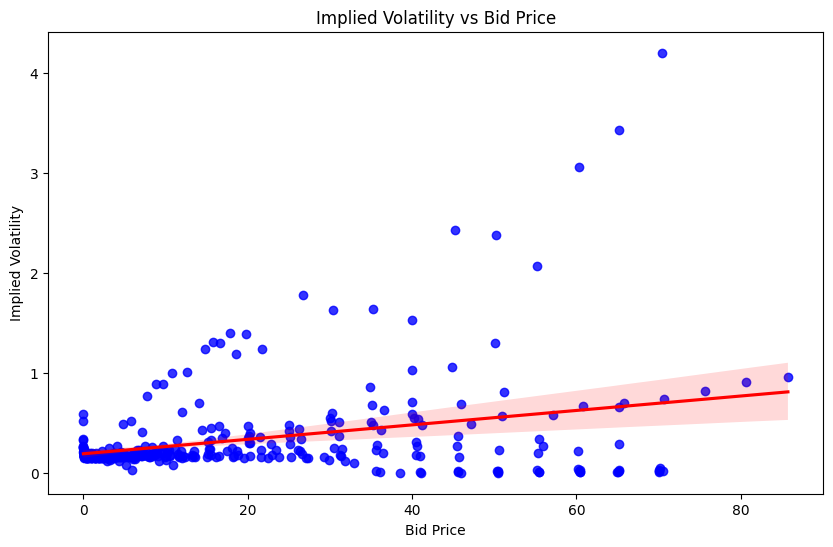

In [7]:
# Scatterplot with line of best fit
plt.figure(figsize=(10, 6))
sns.regplot(x=data['bid'], y=data['implied_volatility'], scatter=True, color='blue', line_kws={"color": "red"})
plt.xlabel('Bid Price')
plt.ylabel('Implied Volatility')
plt.title('Implied Volatility vs Bid Price')
plt.show()

In [8]:
import functools

@functools.lru_cache
def get_predictors(symbol, date):
    ticker = yf.Ticker(symbol)
    start_date = date - timedelta(days=14)
    hist = ticker.history(interval="1d", start=start_date, end=date)
    
    log_returns = np.log(hist['Close'] / hist['Close'].shift(1))
    
    return {
        "volume": hist["Volume"].mean(),
        "historial_volatility": log_returns.std() * np.sqrt(252),
        "avg_stock_price": np.mean(hist['Close']),
    }

get_predictors('aapl', datetime.now())

{'volume': np.float64(40723339.7),
 'historial_volatility': np.float64(0.1881160373419146),
 'avg_stock_price': np.float64(232.53000030517578)}

In [9]:
# compute training data
train_data = [] # [(symbol, date, actual volatility)]

stocks = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'NVDA', 'NFLX', 'V', 'JPM', 'UNH', 'PG', 'DIS', 'VZ', 
    'INTC', 'CSCO', 'PYPL', 'PEP', 'KO', 'XOM', 'CVX', 'NKE', 'LLY', 'MRK', 'PFE', 'BA', 'WMT', 'MA', 'ORCL', 
    'ADBE', 'T', 'GS', 'HD', 'C', 'MCD', 'QCOM', 'IBM', 'HON', 'ABBV', 'LMT', 'AMGN', 'TMO', 'MDT', 'RTX', 'COST', 
    'LOW', 'TXN', 'MO', 'SBUX', 'DHR', 'AXP', 'SPG', 'MMM', 'UPS', 'BK', 'BLK', 'CAT', 'FDX', 'JNJ', 'GE',
    'MMM', 'CRM', 'AMD', 'F', 'GM', 'ZTS', 'NOW', 'PANW', 'SHOP', 'ADP', 'CSX', 'PLTR', 'SPCE', 'BABA', 
    'PINS', 'SQ', 'UBER', 'LYFT', 'DKNG', 'ROKU', 'ZM', 'DOCU', 'SNOW', 'TWLO', 'TTD', 'PDD', 'BIDU', 'JD', 'NTES'
]
start_date = datetime.now() - timedelta(days=2*365)
dates = [start_date + timedelta(days=i) for i in range(0, 2*365-30, 50)]

dataset = list(product(stocks, dates))

import functools

@functools.lru_cache
def get_historical_volatility(symbol, start, end):
    ticker = yf.Ticker(symbol)
    stock_data = ticker.history(interval="1d", start=start, end=end)

    log_returns = np.log(stock_data['Close'] / stock_data['Close'].shift(1))

    return log_returns.std() * np.sqrt(252)

def data_to_df(stock_date_list):
    train_data = [(stock, date, *get_predictors(stock, date).values(), get_historical_volatility(stock, date, date + timedelta(days=7))) for stock, date in stock_date_list]
    return pd.DataFrame(train_data, columns=['Stock', 'Date', 'Volume', 'Historical Volatility', 'Stock Price', 'Volatility']).dropna()

In [12]:
training_df = pd.read_csv("analysis_dataset.csv")

In [13]:
training_df['Log Volatility'] = np.log(training_df['Volatility'])

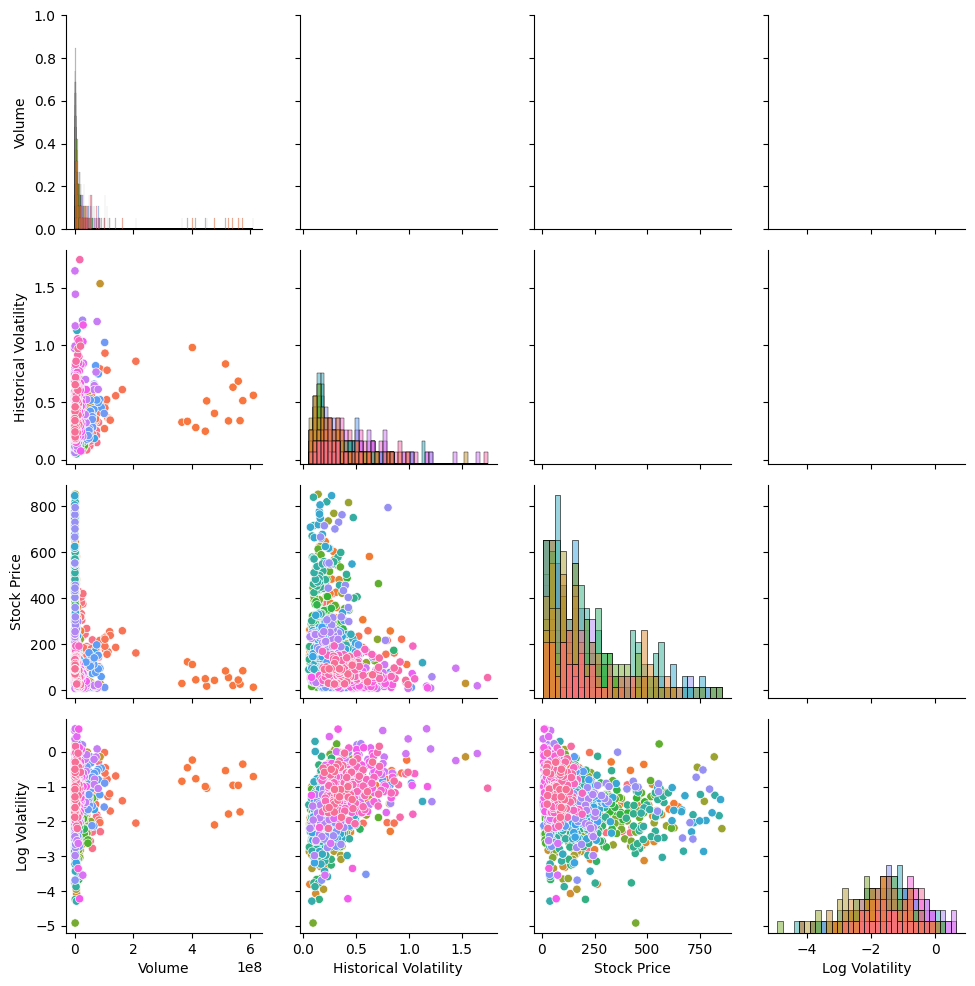

In [29]:
g = sns.PairGrid(training_df, vars=['Volume', 'Historical Volatility', 'Stock Price', 'Log Volatility'], hue='Stock')
g.map_diag(sns.histplot)
g.map_lower(sns.scatterplot)
plt.savefig("log_volatility_pair.png")

In [22]:
data_X = training_df[['Volume', 'Historical Volatility', 'Stock Price']]
data_y = training_df['Log Volatility']

X_train, X_test, y_train, y_test = train_test_split(
    data_X, data_y, test_size=0.2, random_state=42
)

regr = linear_model.LinearRegression()
regr.fit(X_train, y_train)

# save model to file
pickler = pkl.Pickler(open("log_lin_regr.pkl", "wb"))
pickler.dump(regr)

print(regr.coef_, regr.intercept_)

[ 5.24588445e-10  1.43353392e+00 -2.64027934e-04] -1.9265760450659102


In [23]:
y_pred = regr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
naive_err = np.mean(np.abs(np.diff(y_test)))
mase = mae / naive_err
r2 = r2_score(y_test, y_pred)

print(f'MAE: {mae}')
print(f'RMSE: {rmse}')
print(f'MASE: {mase}')
print(f'R²: {r2}')
print(f"Linear regression & {mae:.3f} & {rmse:.3f} & {mase:.3f} & {r2:.3f}")

MAE: 0.5402136821288125
RMSE: 0.7049359530917704
MASE: 0.6563054441521472
R²: 0.21851696561287004
Linear regression & 0.540 & 0.705 & 0.656 & 0.219


In [24]:
stocks = ['NVDA', 'AAPL', 'GOOG', 'TSLA', 'AMZN', 'MSFT', 'META', 'AVGO',
          'CRM', 'NFLX', 'KO', 'JPM', 'CVX', 'BA', 'WMT', 'SHEL', 'IAG',
          'BP', 'JD', 'WDS', 'BHP', 'CSL', 'SAP', 'DTE', 'LIN', 'SHOP',
          'ENB', 'TD', 'BNS', 'CNQ']
date = datetime(2024, 9, 12)

stockdata_df = data_to_df(zip(stocks, [date] * len(stocks)))

stockdata_df['Predictions'] = regr.predict(stockdata_df[['Volume', 'Historical Volatility', 'Stock Price']])

stockdata_df[['Stock', 'Date', 'Predictions']].to_csv('actual_predictions.csv', index=False)

In [25]:
# Create linear regression object
ridge_regr = linear_model.Lasso(alpha=0.05)

# Train the model using the training sets
ridge_regr.fit(X_train, y_train)

print(ridge_regr.coef_, ridge_regr.intercept_)

ridge_y_pred = regr.predict(X_test)

mae = mean_absolute_error(y_test, ridge_y_pred)
mse = mean_squared_error(y_test, ridge_y_pred)
rmse = np.sqrt(mse)
naive_err = np.mean(np.abs(np.diff(y_test)))
mase = mae / naive_err
r2 = r2_score(y_test, ridge_y_pred)

# Print results
print(f'MAE: {mae}')
print(f'RMSE: {rmse}')
print(f'MASE: {mase}')
print(f'R²: {r2}')
print(f"Ridge regression & {mae:.3f} & {rmse:.3f} & {mase:.3f} & {r2:.3f}\\")

[ 1.28933056e-09  1.01026580e-01 -6.13594209e-04] -1.491792983492284
MAE: 0.5402136821288125
RMSE: 0.7049359530917704
MASE: 0.6563054441521472
R²: 0.21851696561287004
		Ridge regression & 0.540 & 0.705 & 0.656 & 0.219\


MAE: 0.5218990146941161
RMSE: 0.6841352463242728
MASE: 0.6340549600513741
R²: 0.2639553447250571
Gradient Boosting & 0.522 & 0.684 & 0.634 & 0.264\\


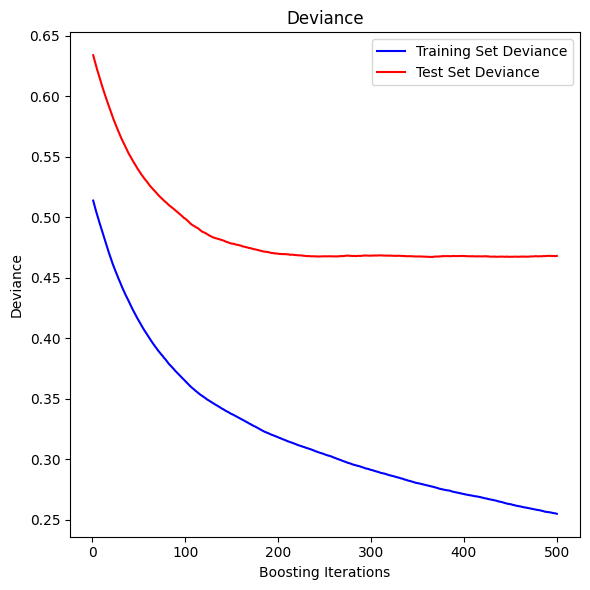

In [26]:
# gradient boost
import sklearn.ensemble as ensemble

params = {
    "n_estimators": 500,
    "max_depth": 4,
    "min_samples_split": 5,
    "learning_rate": 0.01,
    "loss": "squared_error",
}

gb_regr = ensemble.GradientBoostingRegressor(**params)
gb_regr.fit(X_train, y_train)

gb_y_pred = gb_regr.predict(X_test)

pickler = pkl.Pickler(open("log_gradient_boost_regr.pkl", "wb"))
pickler.dump(gb_regr)

mae = mean_absolute_error(y_test, gb_y_pred)
mse = mean_squared_error(y_test, gb_y_pred)
rmse = np.sqrt(mse)
naive_err = np.mean(np.abs(np.diff(y_test)))
mase = mae / naive_err
gbr2 = r2_score(y_test, gb_y_pred)

# Print results
print(f'MAE: {mae}')
print(f'RMSE: {rmse}')
print(f'MASE: {mase}')
print(f'R²: {gbr2}')
print(f"Gradient Boosting & {mae:.3f} & {rmse:.3f} & {mase:.3f} & {gbr2:.3f}\\\\")

test_score = np.zeros((params["n_estimators"],), dtype=np.float64)
for i, y_pred in enumerate(gb_regr.staged_predict(X_test)):
    test_score[i] = mean_squared_error(y_test, y_pred)

fig = plt.figure(figsize=(6, 6))
plt.subplot(1, 1, 1)
plt.title("Deviance")
plt.plot(
    np.arange(params["n_estimators"]) + 1,
    gb_regr.train_score_,
    "b-",
    label="Training Set Deviance",
)
plt.plot(
    np.arange(params["n_estimators"]) + 1, test_score, "r-", label="Test Set Deviance"
)
plt.legend(loc="upper right")
plt.xlabel("Boosting Iterations")
plt.ylabel("Deviance")
fig.tight_layout()
plt.show()

In [27]:
import sklearn.neighbors as neighbors
from sklearn.preprocessing import StandardScaler

# Create knn regression object
knn_regr = neighbors.KNeighborsRegressor(n_neighbors=5, weights='distance', p=2)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_regr.fit(X_train_scaled, y_train)
knn_y_pred = knn_regr.predict(X_test_scaled)

pickler = pkl.Pickler(open("log_knn_regr.pkl", "wb"))
pickler.dump(knn_regr)

mae = mean_absolute_error(y_test, knn_y_pred)
mse = mean_squared_error(y_test, knn_y_pred)
rmse = np.sqrt(mse)
naive_err = np.mean(np.abs(np.diff(y_test)))
mase = mae / naive_err
r2 = r2_score(y_test, knn_y_pred)

# Print results
print(f'MAE: {mae}')
print(f'RMSE: {rmse}')
print(f'MASE: {mase}')
print(f'R²: {r2}')
print(f"KNN & {mae:.3f} & {rmse:.3f} & {mase:.3f} & {gbr2:.3f}\\\\")

[-1.62641054 -0.89106717 -2.43815553 -1.51534107 -1.42459023 -1.50901118
 -2.17539916 -1.94981423 -1.72444426 -1.49400673 -1.64716001 -2.1920907
 -1.02651966 -0.73725514 -1.000242   -1.35296598 -1.73588233 -1.49752359
 -1.49848063 -1.64327133 -1.32444806 -1.01454907 -1.05615103 -1.82892433
 -2.35066368 -0.93028268 -2.12671891 -0.95098577 -1.68387794 -1.09722843
 -0.95388454 -1.65636493 -1.92645002 -2.04763047 -1.97907719 -2.00352814
 -0.78610646 -2.51845345 -1.37985973 -1.23890367 -1.44307545 -1.66606617
 -2.05147485 -0.81539436 -1.16436335 -2.45982704 -1.58283502 -1.04237092
 -1.20019576 -1.26770023 -2.37191451 -1.57511734 -1.92333299 -0.74792009
 -2.12726365 -1.19155443 -1.4171571  -1.82236695 -1.6245604  -1.48185581
 -1.206025   -2.06332451 -0.98377522 -1.5241119  -2.01716512 -2.19223515
 -1.46118529 -0.76176285 -1.12490515 -1.06743112 -1.60538648 -1.44203224
 -1.19462664 -0.90577232 -0.3992679  -2.17787936 -0.72091483 -2.38161713
 -0.84285405 -2.39426792 -0.94837744 -1.18668304 -1.

In [28]:
rf_regr = ensemble.RandomForestRegressor(n_estimators=200)
rf_regr.fit(X_train_scaled, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_y_pred = rf_regr.predict(X_test_scaled)

pickler = pkl.Pickler(open("log_rand_forest_regr.pkl", "wb"))
pickler.dump(rf_regr)

mae = mean_absolute_error(y_test, rf_y_pred)
mse = mean_squared_error(y_test, rf_y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, rf_y_pred)
naive_err = np.mean(np.abs(np.diff(y_test)))
mase = mae / naive_err

# Print results
print(f'MAE: {mae}')
print(f'RMSE: {rmse}')
print(f'MASE: {mase}')
print(f'R²: {r2}')
print(f"Random Forest & {mae:.3f} & {rmse:.3f} & {mase:.3f} & {r2:.3f}\\\\")

MAE: 0.5380704546351212
RMSE: 0.700330256451472
MASE: 0.653701637697962
R²: 0.2286952402453466
Random Forest & 0.538 & 0.700 & 0.654 & 0.229\\
